In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import sys

In [2]:
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))
from src.load_data import load_data, get_data_info
from src.analysis import load_cs_desires, check_paradox, classify_mindset_group, plot_mindset_matrix

In [3]:
cs_desires = load_cs_desires('../data/processed/cs_desires.csv')
cs_metadata = load_cs_desires('../data/processed/cs_metadata.csv')
cs_expert = load_cs_desires('../data/processed/cs_expert.csv')
cs_task = load_cs_desires('../data/processed/cs_task.csv')

Đã đọc file: ../data/processed/cs_desires.csv (1225 dòng)
Đã đọc file: ../data/processed/cs_metadata.csv (311 dòng)
Đã đọc file: ../data/processed/cs_expert.csv (422 dòng)
Đã đọc file: ../data/processed/cs_task.csv (29 dòng)


In [4]:
corr = check_paradox(cs_desires)
cs_desires = classify_mindset_group(cs_desires)

Tương quan Pearson (Desire vs Human Agency): r = -0.121
Số quan sát: 1225
Ngưỡng trung vị: Desire = 3.0, Agency = 3.0

Phân bố 4 nhóm tâm lý:
  Nghich ly uy quyen: 520 (42.4%)
  Delegate hoan toan: 312 (25.5%)
  Giu chat: 243 (19.8%)
  Tho o: 150 (12.2%)


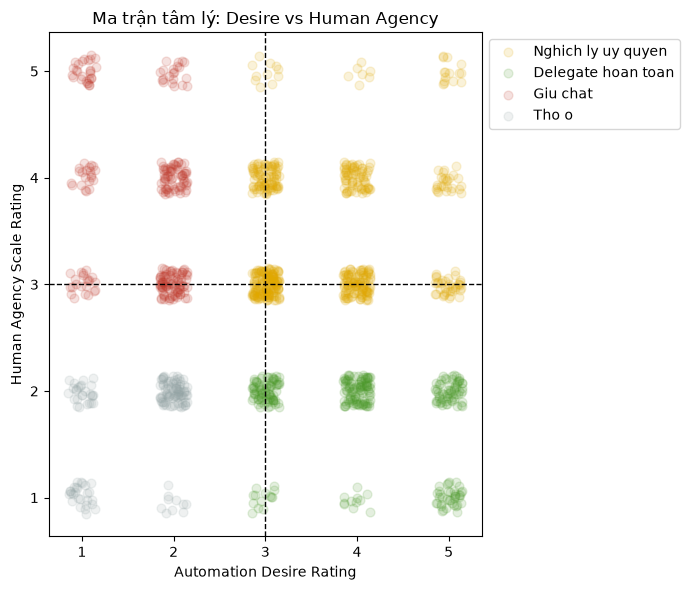

In [5]:
fig = plot_mindset_matrix(cs_desires)
save_path = project_root / 'src' / 'figures' / 'ma_tran_tam_ly.png'
save_path.parent.mkdir(parents=True, exist_ok=True)
plt.close(fig)

Đã đọc file: ../data/processed\cs_desires.csv (1225 dòng)
Ngưỡng trung vị: Desire = 3.0, Agency = 3.0

Phân bố 4 nhóm tâm lý:
  Nghich ly uy quyen: 520 (42.4%)
  Delegate hoan toan: 312 (25.5%)
  Giu chat: 243 (19.8%)
  Tho o: 150 (12.2%)
Lý do muốn TỰ ĐỘNG HÓA:
  Free Time: 48.7%
  Scale: 35.5%
  Human Error: 34.6%
  Repetitive: 32.5%
  Stress: 18.4%
  Difficulty: 13.9%

Lý do muốn GIỮ QUYỀN CON NGƯỜI:
  Domain Knowledge: 33.6%
  Quality Oversight: 31.2%
  Control: 28.1%
  Dynamic: 24.2%
  Empathy: 22.9%
  Ethical: 17.3%
  Physical: 12.9%
Số quan sát nhóm 'Nghich ly uy quyen': 520

Lý do giữ quyền chiếm ưu thế trong nhóm 'Nghich ly uy quyen':
  Domain Knowledge: 50.4%
  Quality Oversight: 48.5%
  Control: 41.9%
  Dynamic: 39.4%
  Empathy: 36.7%
  Ethical: 25.2%
  Physical: 23.5%


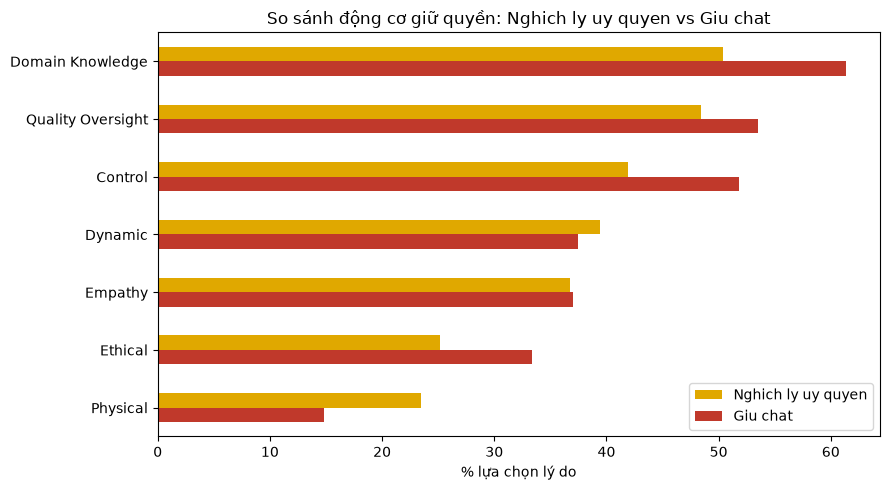

In [6]:
from src.analysis import load_cs_desires, classify_mindset_group, rank_reasons, paradox_group_reasons, compare_groups_reasons

cs_desires = load_cs_desires('../data/processed')
cs_desires = classify_mindset_group(cs_desires)

auto_pct, agency_pct = rank_reasons(cs_desires)
paradox_pct = paradox_group_reasons(cs_desires)
compare_df = compare_groups_reasons(cs_desires)

Số nghề đủ điều kiện (>= 20 quan sát): 20

Bảng tỷ lệ 4 nhóm tâm lý theo nghề (%):
Mindset_Group                                    Delegate hoan toan  Giu chat  \
Occupation (O*NET-SOC Title)                                                    
Computer and Information Research Scientists                   18.9      15.1   
Clinical Data Managers                                         31.8       9.1   
Information Technology Project Managers                        13.8      20.0   
Statisticians                                                  27.7      19.1   
Information Security Analysts                                  17.8       8.9   
Computer Systems Engineers/Architects                          19.4      17.7   
Mathematicians                                                 21.1      21.1   
Business Intelligence Analysts                                 34.7      14.3   
Software Quality Assurance Analysts and Testers                23.5      27.2   
Web Developers            

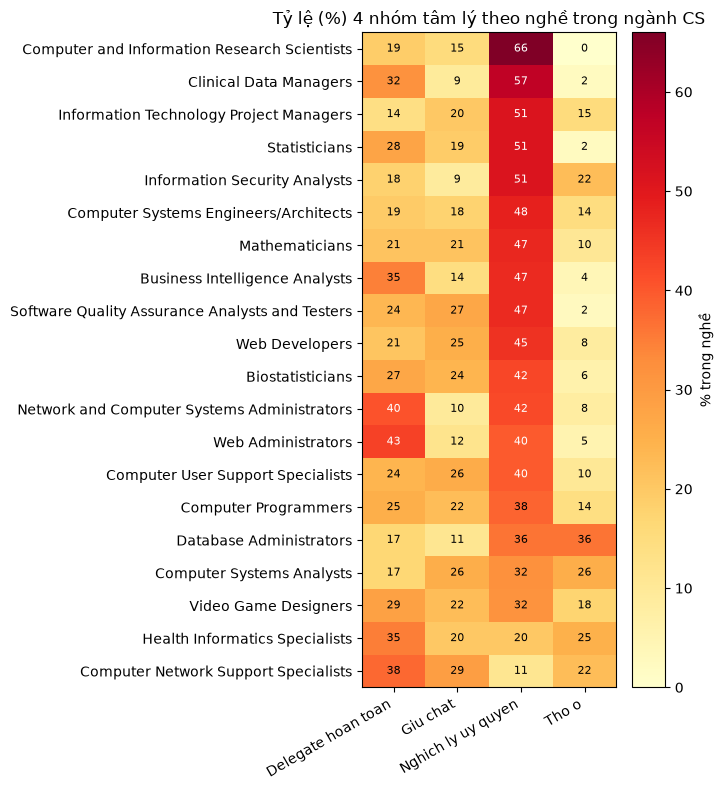

Lý do giữ quyền chiếm ưu thế theo nghề (chỉ trong nhóm 'Nghich ly uy quyen', n >= 10):
                                     Occupation        Top_Reason  Top_Reason_Pct  N
    Network and Computer Systems Administrators Quality Oversight            90.3 31
          Computer Systems Engineers/Architects           Control            86.7 30
                                  Statisticians  Domain Knowledge            83.3 24
              Computer User Support Specialists           Empathy            82.6 23
                           Video Game Designers Quality Oversight            80.0 20
                 Business Intelligence Analysts           Control            69.6 23
                             Web Administrators           Control            69.6 23
                                 Mathematicians  Domain Knowledge            66.7 18
                         Clinical Data Managers  Domain Knowledge            64.0 25
                        Database Administrators Quality Oversig

In [7]:
from src.analysis import occupation_mindset_table, plot_occupation_heatmap, occupation_top_reason

table = occupation_mindset_table(cs_desires)        # bảng % 4 nhóm theo từng nghề
plot_occupation_heatmap(table)                       # heatmap trực quan
top_reasons = occupation_top_reason(cs_desires)

Số task có đủ cả dữ liệu Desire và Capacity: 173
Ngưỡng trung vị (cấp task): Desire = 3.17, Capacity = 3.33

Phân bố 4 vùng Desire x Capacity:
  Vung an toan: 52 (30.1%)
  Vung rao can tam ly: 44 (25.4%)
  Vung uu tien thap: 41 (23.7%)
  Vung rui ro ky thuat: 36 (20.8%)


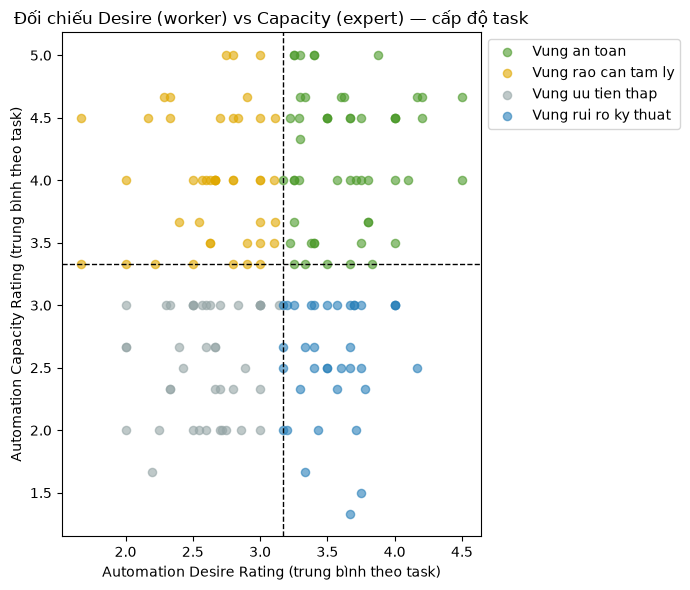

Số task thuộc 'Vung rao can tam ly': 44

Phân bố lý do giữ quyền chiếm ưu thế trong vùng này:
Dominant_Agency_Reason
Control              15
Domain Knowledge     14
Quality Oversight     7
Physical              6
Empathy               1
Dynamic               1
Name: count, dtype: int64

Top 10 task có Capacity cao nhất nhưng Desire thấp (rào cản tâm lý rõ nhất):
                             Occupation  Automation Desire Rating  Automation Capacity Rating Dominant_Agency_Reason
                   Computer Programmers                  3.000000                    5.000000       Domain Knowledge
      Computer User Support Specialists                  2.750000                    5.000000                Control
                         Web Developers                  2.800000                    5.000000       Domain Knowledge
      Computer User Support Specialists                  2.285714                    4.666667       Domain Knowledge
                         Web Developers           

,Task ID,Occupation,Automation Desire Rating,Human Agency Scale Rating,n_desire,Dominant_Agency_Reason,Automation Capacity Rating,n_expert,Zone
7,1276,Computer Programmers,3.000000,2.375000,8,Domain Knowledge,5.000000,2,Vung rao can tam ly
12,1285,Computer User Support Specialists,2.750000,2.875000,8,Control,5.000000,2,Vung rao can tam ly
100,14722,Web Developers,2.800000,3.100000,10,Domain Knowledge,5.000000,2,Vung rao can tam ly
11,1283,Computer User Support Specialists,2.285714,2.857143,7,Domain Knowledge,4.666667,3,Vung rao can tam ly
93,14707,Web Developers,2.900000,3.400000,10,Domain Knowledge,4.666667,3,Vung rao can tam ly
163,18991,Computer Network Support Specialists,2.333333,2.666667,6,Control,4.666667,3,Vung rao can tam ly
21,1313,Database Administrators,1.666667,2.666667,3,Physical,4.500000,2,Vung rao can tam ly
125,16168,Information Technology Project Managers,3.000000,2.900000,10,Domain Knowledge,4.500000,2,Vung rao can tam ly
37,3480,Computer Systems Analysts,2.700000,2.700000,10,Control,4.500000,2,Vung rao can tam ly
17,1299,Database Administrators,2.166667,2.333333,6,Control,4.500000,2,Vung rao can tam ly


In [8]:
from src.analysis import merge_desire_capacity, classify_zone, plot_desire_capacity_matrix, zone_summary

cs_expert = pd.read_csv('../data/processed/cs_expert.csv')

task_df = merge_desire_capacity(cs_desires, cs_expert)   # gộp ở cấp độ TASK (không phải cấp dòng)
task_df = classify_zone(task_df)                          # chia 4 vùng Desire x Capacity
plot_desire_capacity_matrix(task_df)                      # vẽ ma trận
zone_summary(task_df)                                      # đào sâu vùng "rào cản tâm lý"